In [1]:
from pathlib import Path
import os

# Project
PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")

# Original BRISC2025 dataset
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

print("Project directory:")
print(PROJECT_DIR)

print("\nDataset directory:")
print(DATASET_DIR)

print("\nDataset exists:", DATASET_DIR.exists())

Project directory:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor

Dataset directory:
D:\MSC Bioinformatics\INTERNSHIP\brisc2025

Dataset exists: True


In [2]:
print("Contents of BRISC2025:\n")

for item in sorted(DATASET_DIR.iterdir()):
    if item.is_dir():
        print(f"[DIR]  {item.name}")
    else:
        print(f"[FILE] {item.name}")

Contents of BRISC2025:

[DIR]  classification_task
[FILE] manifest.csv
[FILE] manifest.csv.sha256
[FILE] manifest.json
[FILE] manifest.json.sha256
[FILE] README.md
[DIR]  segmentation_task


In [3]:
classification_dir = DATASET_DIR / "classification_task"

print("Classification directory:", classification_dir)
print("\nContents:\n")

for item in sorted(classification_dir.iterdir()):
    print(item.name)

Classification directory: D:\MSC Bioinformatics\INTERNSHIP\brisc2025\classification_task

Contents:

test
train


In [4]:
for split in ["train", "test"]:
    split_dir = classification_dir / split
    
    print(f"\n{split.upper()}")
    print("-" * 40)
    
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            count = len(list(class_dir.glob("*")))
            print(f"{class_dir.name}: {count} files")


TRAIN
----------------------------------------
glioma: 1147 files
meningioma: 1329 files
no_tumor: 1067 files
pituitary: 1457 files

TEST
----------------------------------------
glioma: 254 files
meningioma: 306 files
no_tumor: 140 files
pituitary: 300 files


In [5]:
from PIL import Image
import random

# Collect image files from the classification training set
train_dir = classification_dir / "train"

image_files = []

for class_dir in sorted(train_dir.iterdir()):
    if class_dir.is_dir():
        for file in class_dir.iterdir():
            if file.is_file():
                image_files.append(file)

print("Total training images found:", len(image_files))

# Inspect one random image
sample_path = random.choice(image_files)

print("\nSample image:")
print("Path:", sample_path)
print("Class:", sample_path.parent.name)

img = Image.open(sample_path)

print("Format:", img.format)
print("Mode:", img.mode)
print("Size:", img.size)

Total training images found: 5000

Sample image:
Path: D:\MSC Bioinformatics\INTERNSHIP\brisc2025\classification_task\train\pituitary\brisc2025_train_03983_pi_co_t1.jpg
Class: pituitary
Format: JPEG
Mode: RGB
Size: (512, 512)


In [6]:
from PIL import Image
import random

# Collect image files from the classification training set
train_dir = classification_dir / "train"

image_files = []

for class_dir in sorted(train_dir.iterdir()):
    if class_dir.is_dir():
        for file in class_dir.iterdir():
            if file.is_file():
                image_files.append(file)

print("Total training images found:", len(image_files))

sample_path = random.choice(image_files)

print("\nSample image:")
print("Path:", sample_path)
print("Class:", sample_path.parent.name)

img = Image.open(sample_path)

print("Format:", img.format)
print("Mode:", img.mode)
print("Size:", img.size)

Total training images found: 5000

Sample image:
Path: D:\MSC Bioinformatics\INTERNSHIP\brisc2025\classification_task\train\no_tumor\brisc2025_train_02994_no_co_t1.jpg
Class: no_tumor
Format: JPEG
Mode: RGB
Size: (216, 369)


In [7]:
from collections import Counter

dimension_counts = Counter()

for file_path in image_files:
    try:
        with Image.open(file_path) as image:
            dimension_counts[image.size] += 1
    except Exception as e:
        print(f"Could not read: {file_path}")
        print(e)

print("Unique image dimensions:", len(dimension_counts))
print("\nDimensions and counts:")

for size, count in dimension_counts.most_common():
    print(f"{size}: {count}")

Unique image dimensions: 167

Dimensions and counts:
(512, 512): 4120
(369, 369): 323
(216, 369): 277
(256, 256): 27
(187, 369): 21
(202, 369): 19
(225, 225): 13
(210, 369): 12
(236, 236): 11
(442, 442): 6
(455, 500): 3
(213, 237): 2
(485, 510): 2
(554, 554): 2
(200, 223): 2
(201, 251): 2
(212, 237): 2
(341, 395): 2
(233, 218): 2
(200, 210): 2
(733, 781): 2
(236, 269): 2
(474, 474): 2
(250, 270): 1
(472, 546): 1
(441, 427): 1
(507, 605): 1
(338, 345): 1
(369, 398): 1
(591, 650): 1
(351, 398): 1
(341, 377): 1
(491, 624): 1
(314, 358): 1
(257, 307): 1
(300, 345): 1
(291, 340): 1
(318, 354): 1
(315, 341): 1
(278, 306): 1
(513, 522): 1
(312, 401): 1
(300, 412): 1
(205, 251): 1
(204, 249): 1
(323, 342): 1
(216, 216): 1
(341, 372): 1
(273, 326): 1
(305, 337): 1
(304, 410): 1
(208, 243): 1
(200, 252): 1
(480, 480): 1
(224, 219): 1
(200, 235): 1
(209, 241): 1
(211, 239): 1
(215, 234): 1
(214, 216): 1
(214, 235): 1
(210, 240): 1
(213, 236): 1
(224, 216): 1
(295, 394): 1
(230, 241): 1
(219, 234)

In [8]:
format_counts = Counter()
mode_counts = Counter()
corrupt_files = []

for file_path in image_files:
    try:
        with Image.open(file_path) as image:
            image.verify()

        with Image.open(file_path) as image:
            format_counts[image.format] += 1
            mode_counts[image.mode] += 1

    except Exception as e:
        corrupt_files.append((str(file_path), str(e)))

print("Formats:")
for fmt, count in format_counts.items():
    print(f"{fmt}: {count}")

print("\nColor modes:")
for mode, count in mode_counts.items():
    print(f"{mode}: {count}")

print("\nCorrupt/unreadable files:", len(corrupt_files))

Formats:
JPEG: 5000

Color modes:
RGB: 2716
L: 2284

Corrupt/unreadable files: 0


In [9]:
from collections import defaultdict, Counter

class_mode_counts = defaultdict(Counter)

for file_path in image_files:
    try:
        with Image.open(file_path) as image:
            class_name = file_path.parent.name
            class_mode_counts[class_name][image.mode] += 1
    except Exception:
        pass

print("Image mode distribution by class:\n")

for class_name in sorted(class_mode_counts):
    print(f"{class_name}:")
    for mode, count in class_mode_counts[class_name].items():
        print(f"    {mode}: {count}")

Image mode distribution by class:

glioma:
    RGB: 109
    L: 1038
meningioma:
    RGB: 780
    L: 549
no_tumor:
    RGB: 1067
pituitary:
    RGB: 760
    L: 697


In [10]:
class_dimension_counts = defaultdict(Counter)

for file_path in image_files:
    try:
        with Image.open(file_path) as image:
            class_name = file_path.parent.name
            class_dimension_counts[class_name][image.size] += 1
    except Exception:
        pass

print("Most common dimensions by class:\n")

for class_name in sorted(class_dimension_counts):
    print(f"\n{class_name}:")
    
    for size, count in class_dimension_counts[class_name].most_common(10):
        print(f"    {size}: {count}")

Most common dimensions by class:


glioma:
    (512, 512): 1147

meningioma:
    (512, 512): 1201
    (225, 225): 8
    (455, 500): 3
    (442, 442): 3
    (213, 237): 2
    (485, 510): 2
    (554, 554): 2
    (200, 223): 2
    (201, 251): 2
    (212, 237): 2

no_tumor:
    (512, 512): 354
    (369, 369): 323
    (216, 369): 277
    (187, 369): 21
    (202, 369): 19
    (210, 369): 12
    (236, 236): 11
    (225, 225): 5
    (442, 442): 2
    (233, 218): 2

pituitary:
    (512, 512): 1418
    (256, 256): 24
    (474, 474): 2
    (360, 378): 1
    (470, 432): 1
    (400, 400): 1
    (685, 681): 1
    (202, 202): 1
    (1280, 1280): 1
    (721, 903): 1


In [11]:
import matplotlib.pyplot as plt
import random

classes = ["glioma", "meningioma", "no_tumor", "pituitary"]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, class_name in zip(axes.ravel(), classes):
    class_dir = train_dir / class_name
    
    files = [
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    
    sample_path = random.choice(files)
    
    with Image.open(sample_path) as image:
        ax.imshow(image, cmap="gray")
    
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

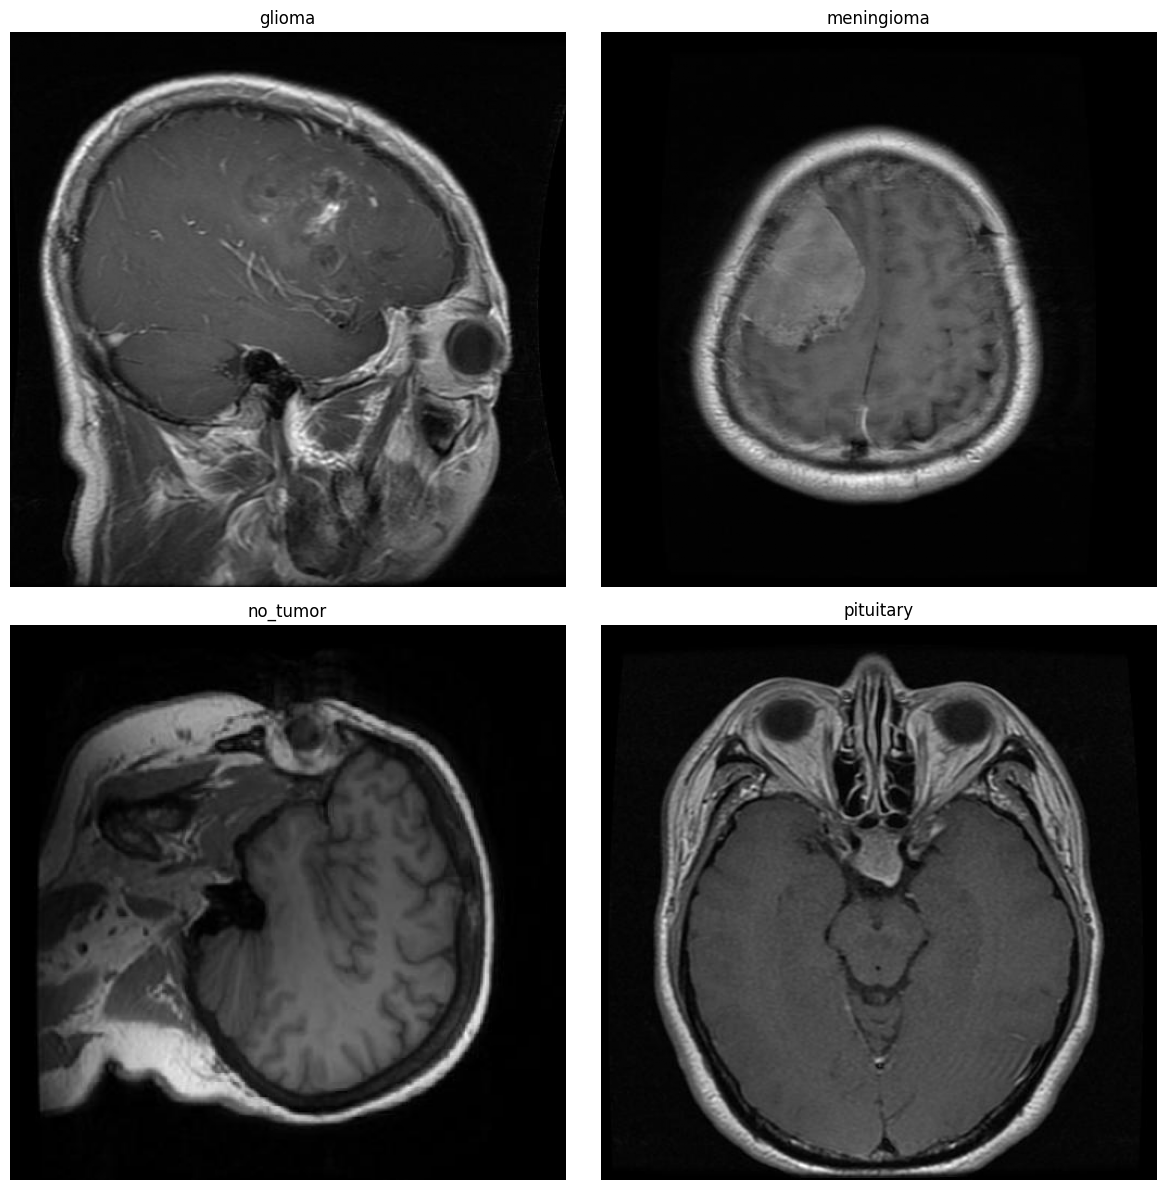

In [12]:
import matplotlib.pyplot as plt
import random

classes = ["glioma", "meningioma", "no_tumor", "pituitary"]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, class_name in zip(axes.ravel(), classes):
    class_dir = train_dir / class_name

    files = [
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    sample_path = random.choice(files)

    with Image.open(sample_path) as image:
        ax.imshow(image, cmap="gray")

    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
for class_name in classes:
    class_dir = train_dir / class_name
    
    files = sorted([
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])
    
    print(f"\n{class_name}:")
    for file in files[:5]:
        print(" ", file.name)


glioma:
  brisc2025_train_00001_gl_ax_t1.jpg
  brisc2025_train_00002_gl_ax_t1.jpg
  brisc2025_train_00003_gl_ax_t1.jpg
  brisc2025_train_00004_gl_ax_t1.jpg
  brisc2025_train_00005_gl_ax_t1.jpg

meningioma:
  brisc2025_train_01148_me_ax_t1.jpg
  brisc2025_train_01149_me_ax_t1.jpg
  brisc2025_train_01150_me_ax_t1.jpg
  brisc2025_train_01151_me_ax_t1.jpg
  brisc2025_train_01152_me_ax_t1.jpg

no_tumor:
  brisc2025_train_02477_no_ax_t1.jpg
  brisc2025_train_02478_no_ax_t1.jpg
  brisc2025_train_02479_no_ax_t1.jpg
  brisc2025_train_02480_no_ax_t1.jpg
  brisc2025_train_02481_no_ax_t1.jpg

pituitary:
  brisc2025_train_03544_pi_ax_t1.jpg
  brisc2025_train_03545_pi_ax_t1.jpg
  brisc2025_train_03546_pi_ax_t1.jpg
  brisc2025_train_03547_pi_ax_t1.jpg
  brisc2025_train_03548_pi_ax_t1.jpg


In [14]:
import pandas as pd

manifest_path = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(manifest_path)

print("Manifest shape:", manifest.shape)

print("\nColumns:")
print(manifest.columns.tolist())

print("\nFirst 5 rows:")
display(manifest.head())

ModuleNotFoundError: No module named 'pandas'

In [15]:
import pandas as pd

manifest_path = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(manifest_path)

print("Manifest shape:", manifest.shape)

print("\nColumns:")
print(manifest.columns.tolist())

print("\nFirst 5 rows:")
display(manifest.head())

Manifest shape: (15586, 16)

Columns:
['relative_path', 'filename', 'task', 'split', 'index', 'tumor_code', 'tumor_label', 'plane_code', 'plane_label', 'sequence', 'is_mask', 'linked_image', 'width', 'height', 'file_size_bytes', 'sha256']

First 5 rows:


,relative_path,filename,task,split,index,tumor_code,tumor_label,plane_code,plane_label,sequence,is_mask,linked_image,width,height,file_size_bytes,sha256
0,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00001_gl_ax_t1.jpg,classification,test,1,gl,glioma,ax,axial,T1,False,NaN,512,512,25826,b513a83f68e486f45159b004d356782e78284014532151...
1,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00002_gl_ax_t1.jpg,classification,test,2,gl,glioma,ax,axial,T1,False,NaN,512,512,20982,5b4e4a0f482cb68955c340205d475f25c3a30718bd3b48...
2,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00003_gl_ax_t1.jpg,classification,test,3,gl,glioma,ax,axial,T1,False,NaN,512,512,13285,6fd1918b39e7a7f92fa5652d7802583f3251fed50a23ec...
3,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00004_gl_ax_t1.jpg,classification,test,4,gl,glioma,ax,axial,T1,False,NaN,512,512,26137,216b65a45d7effb4ebce1c9893f97d12449c9da777f818...
4,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00005_gl_ax_t1.jpg,classification,test,5,gl,glioma,ax,axial,T1,False,NaN,512,512,21709,c35734545021ab5a4f55fb87e08732e26fb16abe887927...


In [16]:
print("TASK DISTRIBUTION")
print(manifest["task"].value_counts())

print("\nSPLIT DISTRIBUTION")
print(manifest["split"].value_counts())

print("\nTASK × SPLIT")
display(
    pd.crosstab(
        manifest["task"],
        manifest["split"],
        margins=True
    )
)

TASK DISTRIBUTION
task
segmentation      9586
classification    6000
Name: count, dtype: int64

SPLIT DISTRIBUTION
split
train    12866
test      2720
Name: count, dtype: int64

TASK × SPLIT


split,test,train,All
task,,,
classification,1000,5000,6000
segmentation,1720,7866,9586
All,2720,12866,15586


In [17]:
classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

print("Classification records:", len(classification_manifest))

print("\nClass distribution:")
print(classification_manifest["tumor_label"].value_counts())

print("\nClass × Split:")
display(
    pd.crosstab(
        classification_manifest["tumor_label"],
        classification_manifest["split"],
        margins=True
    )
)

Classification records: 6000

Class distribution:
tumor_label
pituitary     1757
meningioma    1635
glioma        1401
no_tumor      1207
Name: count, dtype: int64

Class × Split:


split,test,train,All
tumor_label,,,
glioma,254,1147,1401
meningioma,306,1329,1635
no_tumor,140,1067,1207
pituitary,300,1457,1757
All,1000,5000,6000


In [18]:
classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

print("IMAGE MODE DISTRIBUTION BY CLASS AND SPLIT")
print()

for split_name in ["train", "test"]:
    print(f"===== {split_name.upper()} =====")
    
    split_df = classification_manifest[
        classification_manifest["split"] == split_name
    ].copy()

    # Get the actual image paths
    split_df["image_path"] = split_df["relative_path"].apply(
        lambda x: DATASET_DIR / x
    )

    mode_records = []

    for _, row in split_df.iterrows():
        try:
            with Image.open(row["image_path"]) as img:
                mode_records.append({
                    "tumor_label": row["tumor_label"],
                    "mode": img.mode
                })
        except Exception:
            pass

    mode_df = pd.DataFrame(mode_records)

    display(
        pd.crosstab(
            mode_df["tumor_label"],
            mode_df["mode"],
            margins=True
        )
    )

IMAGE MODE DISTRIBUTION BY CLASS AND SPLIT

===== TRAIN =====


mode,L,RGB,All
tumor_label,,,
glioma,1038,109,1147
meningioma,549,780,1329
no_tumor,0,1067,1067
pituitary,697,760,1457
All,2284,2716,5000


===== TEST =====


mode,L,RGB,All
tumor_label,,,
glioma,189,65,254
meningioma,160,146,306
no_tumor,0,140,140
pituitary,233,67,300
All,582,418,1000


In [19]:
print("PLANE DISTRIBUTION — CLASSIFICATION DATASET")

plane_table = pd.crosstab(
    classification_manifest["tumor_label"],
    classification_manifest["plane_label"],
    margins=True
)

display(plane_table)

print("\nPLANE DISTRIBUTION BY SPLIT")

plane_split_table = pd.crosstab(
    [classification_manifest["tumor_label"], classification_manifest["split"]],
    classification_manifest["plane_label"]
)

display(plane_split_table)

PLANE DISTRIBUTION — CLASSIFICATION DATASET


plane_label,axial,coronal,sagittal,All
tumor_label,,,,
glioma,479,511,411,1401
meningioma,560,512,563,1635
no_tumor,404,358,445,1207
pituitary,550,600,607,1757
All,1993,1981,2026,6000



PLANE DISTRIBUTION BY SPLIT


plane_label        axial  coronal  sagittal
tumor_label split                          
glioma      test      85       81        88
            train    394      430       323
meningioma  test     137       86        83
            train    423      426       480
no_tumor    test      52       48        40
            train    352      310       405
pituitary   test     124       90        86
            train    426      510       521

In [20]:
print("SEQUENCE DISTRIBUTION")
print(
    classification_manifest["sequence"]
    .value_counts(dropna=False)
)

print("\nSEQUENCE × CLASS")
display(
    pd.crosstab(
        classification_manifest["tumor_label"],
        classification_manifest["sequence"],
        margins=True
    )
)

SEQUENCE DISTRIBUTION
sequence
T1    6000
Name: count, dtype: int64

SEQUENCE × CLASS


sequence,T1,All
tumor_label,,
glioma,1401,1401
meningioma,1635,1635
no_tumor,1207,1207
pituitary,1757,1757
All,6000,6000


In [21]:
print("IMAGE DIMENSION DISTRIBUTION")
print(
    classification_manifest
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print("\nUNIQUE DIMENSIONS:")
print(
    classification_manifest[["width", "height"]]
    .drop_duplicates()
    .shape[0]
)

print("\nDIMENSIONS BY CLASS:")
display(
    pd.crosstab(
        classification_manifest["tumor_label"],
        [
            classification_manifest["width"],
            classification_manifest["height"]
        ]
    )
)

IMAGE DIMENSION DISTRIBUTION
width  height
512    512       4881
369    369        363
216    369        354
256    256         32
187    369         21
225    225         20
202    369         19
210    369         12
236    236         11
442    442         10
201    251          5
554    554          5
455    500          5
341    395          4
200    223          4
212    237          4
210    240          4
213    237          3
289    354          2
441    427          2
dtype: int64

UNIQUE DIMENSIONS:
183

DIMENSIONS BY CLASS:


width       174  180  187  200                      201        ... 722  733   \
height      230  218  369  210  223  235  236  252  207  210   ... 690  781    
tumor_label                                                    ...             
glioma         0    0    0    0    0    0    0    0    0    0  ...    0    0   
meningioma     1    1    0    0    4    2    1    2    2    0  ...    2    0   
no_tumor       0    0   21    2    0    0    0    0    0    0  ...    0    2   
pituitary      0    0    0    0    0    0    0    0    0    1  ...    0    0   

width       825  900  940  1024 1149 1275 1280 1365  
height      993  741  900  1024 1019 1427 1280 1365  
tumor_label                                          
glioma         0    0    0    0    0    0    0    0  
meningioma     1    0    0    0    1    1    0    0  
no_tumor       0    0    0    1    0    0    0    0  
pituitary      0    1    1    0    0    0    1    1  

[4 rows x 183 columns]

In [22]:
dimension_counts = (
    classification_manifest
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Number of unique dimensions:", len(dimension_counts))

print("\nTop 20 most common dimensions:")
display(dimension_counts.head(20))

print("\nImages with 512 × 512 dimensions:")
print(
    classification_manifest[
        (classification_manifest["width"] == 512) &
        (classification_manifest["height"] == 512)
    ].shape[0]
)

print("\nPercentage that are 512 × 512:")
print(
    round(
        (
            (
                (classification_manifest["width"] == 512) &
                (classification_manifest["height"] == 512)
            ).sum()
            / len(classification_manifest)
        ) * 100,
        2
    ),
    "%"
)

Number of unique dimensions: 183

Top 20 most common dimensions:


,width,height,count
157,512,512,4881
126,369,369,363
34,216,369,354
80,256,256,32
2,187,369,21
42,225,225,20
14,202,369,19
23,210,369,12
65,236,236,11
138,442,442,10



Images with 512 × 512 dimensions:
4881

Percentage that are 512 × 512:
81.35 %


In [23]:
print("DUPLICATE SHA-256 CHECK")
print()

hash_counts = classification_manifest["sha256"].value_counts()

duplicate_hashes = hash_counts[hash_counts > 1]

print("Total classification images:", len(classification_manifest))
print("Unique SHA-256 hashes:", classification_manifest["sha256"].nunique())
print("Duplicate SHA-256 hashes:", len(duplicate_hashes))

if len(duplicate_hashes) > 0:
    print("\nDuplicate hash counts:")
    display(duplicate_hashes.head(20))
else:
    print("\nNo identical files found.")

DUPLICATE SHA-256 CHECK

Total classification images: 6000
Unique SHA-256 hashes: 5950
Duplicate SHA-256 hashes: 46

Duplicate hash counts:


sha256
3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b364fd4e4593bf0f268a    4
24f09f91af40e42f2798bbc29df353ce17e6a0c0b533fb923b2fa8f75df6b496    3
7d0738e4f6493b449e20a147b80f674c589dc478dd6b5ccd4fb6ea1c329f0cfe    3
8d7abec740c4d59168bd40626034ce16cc2054a6b46cdf913d1dcaab2671397a    2
f3d00bbb942117c2fb62466414d3c466ca283b678200fe87424e4128b80b2dba    2
94247e44617a135f0ce0ad29fcdff8c7bf484f3f2e4a9826c2ba4267709e5706    2
02799f7863d49de182357e72179f3cc4e65e70099355f2d5aa2e39d356e492d9    2
0de951286256834bd2ddc4e26fe9795265fc200a9f7c85af3fc707eb0bfc8803    2
08690b76457b2b44d58682cece62ec951ef6d30d935ce07df852e97d44434680    2
8a4a14e666a67b90bf01bac1b85170bacf41fda33c7a7394d5e82e83c6f6f324    2
dea65808e631f46024aaa034984629ab8a455f2b951ca7022f12fa9e62b7c8ff    2
6850de4414799ffeff8453156b05e59049870b1e0801f956558ca825482a3a13    2
f55311fb8ccf1b86450233262bd00b176bd1c404e5849b59c0a3cd5e4440626b    2
09b9031e30e757eb6e648686f0ca412357e86895ebbc52d300d2d0a9305fd417    2
451f339dbf4d3

In [24]:
duplicate_hashes = (
    classification_manifest["sha256"]
    .value_counts()
)

duplicate_hashes = duplicate_hashes[
    duplicate_hashes > 1
].index

duplicates = classification_manifest[
    classification_manifest["sha256"].isin(duplicate_hashes)
].copy()

print("Duplicate records:", len(duplicates))
print("Duplicate hashes:", len(duplicate_hashes))

print("\nDUPLICATES BY SPLIT:")
display(
    pd.crosstab(
        duplicates["sha256"],
        duplicates["split"]
    )
)

print("\nTRAIN ↔ TEST DUPLICATE HASHES:")

train_hashes = set(
    duplicates.loc[
        duplicates["split"] == "train",
        "sha256"
    ]
)

test_hashes = set(
    duplicates.loc[
        duplicates["split"] == "test",
        "sha256"
    ]
)

cross_split_hashes = train_hashes.intersection(test_hashes)

print("Duplicate hashes appearing in BOTH train and test:",
      len(cross_split_hashes))

if cross_split_hashes:
    print("\nExamples:")
    display(
        duplicates[
            duplicates["sha256"].isin(cross_split_hashes)
        ][
            ["filename", "tumor_label", "split", "plane_label", "sha256"]
        ].sort_values("sha256").head(30)
    )

Duplicate records: 96
Duplicate hashes: 46

DUPLICATES BY SPLIT:


split,test,train
sha256,,
02799f7863d49de182357e72179f3cc4e65e70099355f2d5aa2e39d356e492d9,1,1
08690b76457b2b44d58682cece62ec951ef6d30d935ce07df852e97d44434680,1,1
092a6997f62fdbaa2bc49469a827ef799ebd70cc75d1b0bf8466c5054241905b,0,2
09b9031e30e757eb6e648686f0ca412357e86895ebbc52d300d2d0a9305fd417,0,2
0de951286256834bd2ddc4e26fe9795265fc200a9f7c85af3fc707eb0bfc8803,2,0
1105b29d6d5b9c2a3c59314b8fc63c661df43e488beb0d996a1bea7079643b42,0,2
1139856fed19589e9f95b7c059324c88a0e77baed54e8e726d496b2cc84b0c8e,0,2
1e1a27e88f2812b4b950fca09bf5f4b8fe20514826756ac69b37b43c0c73214b,0,2
24f09f91af40e42f2798bbc29df353ce17e6a0c0b533fb923b2fa8f75df6b496,0,3



TRAIN ↔ TEST DUPLICATE HASHES:
Duplicate hashes appearing in BOTH train and test: 7

Examples:


,filename,tumor_label,split,plane_label,sha256
826,brisc2025_test_00827_pi_co_t1.jpg,pituitary,test,coronal,02799f7863d49de182357e72179f3cc4e65e70099355f2...
5193,brisc2025_train_04194_pi_co_t1.jpg,pituitary,train,coronal,02799f7863d49de182357e72179f3cc4e65e70099355f2...
750,brisc2025_test_00751_pi_ax_t1.jpg,pituitary,test,axial,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...
4748,brisc2025_train_03749_pi_ax_t1.jpg,pituitary,train,axial,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...
736,brisc2025_test_00737_pi_ax_t1.jpg,pituitary,test,axial,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...
4704,brisc2025_train_03705_pi_ax_t1.jpg,pituitary,train,axial,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...
824,brisc2025_test_00825_pi_co_t1.jpg,pituitary,test,coronal,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
5175,brisc2025_train_04176_pi_co_t1.jpg,pituitary,train,coronal,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
5176,brisc2025_train_04177_pi_co_t1.jpg,pituitary,train,coronal,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
5177,brisc2025_train_04178_pi_co_t1.jpg,pituitary,train,coronal,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...


In [25]:
cross_split_duplicates = duplicates[
    duplicates["sha256"].isin(cross_split_hashes)
].copy()

print("Cross-split duplicate hash groups:", len(cross_split_hashes))

print(
    "Test images involved:",
    cross_split_duplicates[
        cross_split_duplicates["split"] == "test"
    ].shape[0]
)

print(
    "Training images involved:",
    cross_split_duplicates[
        cross_split_duplicates["split"] == "train"
    ].shape[0]
)

print("\nCross-split duplicate details:")
display(
    cross_split_duplicates[
        [
            "filename",
            "tumor_label",
            "plane_label",
            "width",
            "height",
            "split",
            "sha256"
        ]
    ].sort_values("sha256")
)

Cross-split duplicate hash groups: 7
Test images involved: 7
Training images involved: 9

Cross-split duplicate details:


,filename,tumor_label,plane_label,width,height,split,sha256
826,brisc2025_test_00827_pi_co_t1.jpg,pituitary,coronal,512,512,test,02799f7863d49de182357e72179f3cc4e65e70099355f2...
5193,brisc2025_train_04194_pi_co_t1.jpg,pituitary,coronal,512,512,train,02799f7863d49de182357e72179f3cc4e65e70099355f2...
750,brisc2025_test_00751_pi_ax_t1.jpg,pituitary,axial,512,512,test,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...
4748,brisc2025_train_03749_pi_ax_t1.jpg,pituitary,axial,512,512,train,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...
736,brisc2025_test_00737_pi_ax_t1.jpg,pituitary,axial,512,512,test,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...
4704,brisc2025_train_03705_pi_ax_t1.jpg,pituitary,axial,512,512,train,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...
824,brisc2025_test_00825_pi_co_t1.jpg,pituitary,coronal,512,512,test,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
5175,brisc2025_train_04176_pi_co_t1.jpg,pituitary,coronal,512,512,train,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
5176,brisc2025_train_04177_pi_co_t1.jpg,pituitary,coronal,512,512,train,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
5177,brisc2025_train_04178_pi_co_t1.jpg,pituitary,coronal,512,512,train,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...


In [26]:
print("CROSS-SPLIT DUPLICATE LABEL CONSISTENCY")

duplicate_label_check = (
    cross_split_duplicates
    .groupby("sha256")
    .agg(
        labels=("tumor_label", lambda x: sorted(x.unique().tolist())),
        splits=("split", lambda x: sorted(x.unique().tolist())),
        filenames=("filename", list)
    )
    .reset_index()
)

display(duplicate_label_check)

print("\nGroups with conflicting labels:")

conflicting = duplicate_label_check[
    duplicate_label_check["labels"].apply(len) > 1
]

print("Conflicting duplicate groups:", len(conflicting))

if len(conflicting) == 0:
    print("No conflicting labels found among cross-split exact duplicates.")
else:
    display(conflicting)

CROSS-SPLIT DUPLICATE LABEL CONSISTENCY


,sha256,labels,splits,filenames
0,02799f7863d49de182357e72179f3cc4e65e70099355f2...,[pituitary],"[test, train]","[brisc2025_test_00827_pi_co_t1.jpg, brisc2025_..."
1,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...,[pituitary],"[test, train]","[brisc2025_test_00751_pi_ax_t1.jpg, brisc2025_..."
2,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...,[pituitary],"[test, train]","[brisc2025_test_00737_pi_ax_t1.jpg, brisc2025_..."
3,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,[pituitary],"[test, train]","[brisc2025_test_00825_pi_co_t1.jpg, brisc2025_..."
4,960155b05ea8f0ddcbcd3a5e29905c2a4b55832f03e5b7...,[meningioma],"[test, train]","[brisc2025_test_00344_me_ax_t1.jpg, brisc2025_..."
5,b5e17076d1427e41a618f92bc72100c1be4df266082235...,[pituitary],"[test, train]","[brisc2025_test_00834_pi_co_t1.jpg, brisc2025_..."
6,f3d00bbb942117c2fb62466414d3c466ca283b678200fe...,[meningioma],"[test, train]","[brisc2025_test_00352_me_ax_t1.jpg, brisc2025_..."



Groups with conflicting labels:
Conflicting duplicate groups: 0
No conflicting labels found among cross-split exact duplicates.


In [27]:
print("Potential identifier columns:")

for col in manifest.columns:
    unique_count = manifest[col].nunique(dropna=False)
    print(f"{col:20} | unique: {unique_count:6} | total: {len(manifest)}")

Potential identifier columns:
relative_path        | unique:  15586 | total: 15586
filename             | unique:  10793 | total: 15586
task                 | unique:      2 | total: 15586
split                | unique:      2 | total: 15586
index                | unique:   5000 | total: 15586
tumor_code           | unique:      4 | total: 15586
tumor_label          | unique:      4 | total: 15586
plane_code           | unique:      3 | total: 15586
plane_label          | unique:      3 | total: 15586
sequence             | unique:      1 | total: 15586
is_mask              | unique:      2 | total: 15586
linked_image         | unique:   4794 | total: 15586
width                | unique:    124 | total: 15586
height               | unique:    126 | total: 15586
file_size_bytes      | unique:   7532 | total: 15586
sha256               | unique:  10726 | total: 15586
